# Can a new refrigerant replace an old one?

**HFC-134a against two HFO candidates, R-1234yf and R-1234ze(E).**

For thirty years the working fluid in automobile air conditioners was HFC-134a. It is now being
phased down worldwide — its 100-year global warming potential is over a thousand times that of
CO$_2$ — and new vehicles use **R-1234yf**. A second low-GWP candidate, **R-1234ze(E)**, is an
isomer of the first with the same molar mass, and it is *not* used in automobiles.

This notebook asks why. Specifically: **what has to be true of a substitute refrigerant before you
can put it into equipment designed for the old one?** The answer is entirely thermodynamic, it is
not what most people guess, and it takes three constants per fluid to work out.

The properties come from the **Peng–Robinson equation of state**, developed in Chapter 6. Two
things make that a defensible choice rather than a convenience:

- The book already does it. Chapter 5's treatment of this same automobile air conditioner says, in
  print, *"Since an equation of state specific to HFC-134a is not available, the Peng-Robinson
  equation (See Chapter 6) will be used,"* and quotes vapor pressures we reproduce in §2 below.
- **No ideal-gas heat capacity is needed anywhere in this notebook.** Every quantity below is
  either a volume root of the cubic or a *difference of departure functions at a single
  temperature* — and in that difference the ideal-gas contribution cancels identically, because
  both phases sit at the same $T$. That is why three constants suffice.

> This is a **production notebook**: the property table printed in Problem 3.N6 is generated here,
> and written to `output/` at the end. There is deliberately no self-contained/`_thermo` pair —
> a table the book prints needs one authoritative implementation, not two that differ in the last
> digit.

In [1]:
# --- Colab bootstrap -------------------------------------------------------
# No-op when you already have the thermo package alongside this notebook (the
# normal case: you cloned the repository and are running from code/chNN/).
# In Colab there is no repository, so fetch the package and the property data.
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    # rm -rf first: git clone REFUSES an existing directory, and under `!` that
    # failure is silent -- a half-finished earlier clone would otherwise leave an
    # empty thermo/ and surface as a baffling ImportError further down.
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------
sys.path.append("..")

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

from thermo import PengRobinson

R = 8.314        # J/(mol K)

## 1. The three fluids

Peng–Robinson needs the critical temperature, the critical pressure and the acentric factor. That
is all.

⚠️ **These constants are provisional.** $T_c$ and $P_c$ are taken from the critical points of the
reference equations of state (Tillner-Roth & Baehr for R-134a; Richter, McLinden & Lemmon 2011 for
R-1234yf; Thol & Lemmon 2016 for R-1234ze(E)), and $\omega$ was obtained from its own definition,

$$\omega = -\log_{10}\!\left(\frac{P^{\mathrm{vap}}(T_r = 0.7)}{P_c}\right) - 1
\qquad \text{(Eq. 6.6-3)}$$

applied to reference saturation data. The derivation and the citations still to be pinned down are
recorded in `revision_notes/refrigerant_problems.md`. Nothing below should be quoted until they
are.

In [2]:
FLUIDS = {
    # name          M (g/mol)   Tc (K)    Pc (Pa)     omega
    "R-134a":      dict(M=102.031, Tc=374.21, Pc=4.0593e6, omega=0.3269),
    "R-1234yf":    dict(M=114.042, Tc=367.85, Pc=3.3822e6, omega=0.2760),
    "R-1234ze(E)": dict(M=114.042, Tc=382.51, Pc=3.6349e6, omega=0.3132),
}

pr = {name: PengRobinson(Tc=f["Tc"], Pc=f["Pc"], omega=f["omega"], name=name)
      for name, f in FLUIDS.items()}

print(f"{'fluid':<13}{'M':>9}{'Tc (K)':>9}{'Pc (MPa)':>10}{'omega':>8}")
for name, f in FLUIDS.items():
    print(f"{name:<13}{f['M']:>9.3f}{f['Tc']:>9.2f}{f['Pc']/1e6:>10.4f}{f['omega']:>8.4f}")

print("\nThe two HFOs are isomers: same formula C3H2F4, same molar mass, different structure.")
print("Everything that distinguishes them below comes from Tc, Pc and omega.")

fluid                M   Tc (K)  Pc (MPa)   omega
R-134a         102.031   374.21    4.0593  0.3269
R-1234yf       114.042   367.85    3.3822  0.2760
R-1234ze(E)    114.042   382.51    3.6349  0.3132

The two HFOs are isomers: same formula C3H2F4, same molar mass, different structure.
Everything that distinguishes them below comes from Tc, Pc and omega.


## 2. Two checks, before trusting any of it

Never take a property calculation on faith when a published number is available to check it
against. Two are.

**The book's own numbers.** Chapter 5 prints Peng–Robinson vapor pressures for HFC-134a at the two
temperatures an automobile air conditioner works between: **3.484 bar at 5 °C** and **14.96 bar at
55 °C**. If our constants are on the same basis the book used, we must reproduce them.

**The normal boiling points.** Each fluid's atmospheric boiling point is an independently measured
constant, so PR's prediction of the temperature at which $P^{\mathrm{vap}} = 101.325$ kPa is a test
the equation can fail.

In [3]:
print("Check 1 -- the book's printed PR vapor pressures for HFC-134a (Chapter 5):")
for T_C, book in ((5.0, 3.484), (55.0, 14.96)):
    P = pr["R-134a"].vapor_pressure(T_C + 273.15) / 1e5
    print(f"   {T_C:>5.1f} C :  this notebook {P:8.3f} bar   book {book:6.3f} bar"
          f"   ({100*(P-book)/book:+.2f} %)")

print("\nCheck 2 -- normal boiling point, where P_vap = 1 atm:")
NBP_REF = {"R-134a": -26.07, "R-1234yf": -29.49, "R-1234ze(E)": -18.97}   # C, reference EOS
for name in FLUIDS:
    T = brentq(lambda t: pr[name].vapor_pressure(t) - 101325.0, 180.0, FLUIDS[name]["Tc"] - 1.0)
    ref = NBP_REF[name]
    print(f"   {name:<13} PR {T-273.15:7.2f} C    reference {ref:7.2f} C    ({T-273.15-ref:+.2f} K)")

Check 1 -- the book's printed PR vapor pressures for HFC-134a (Chapter 5):
     5.0 C :  this notebook    3.484 bar   book  3.484 bar   (+0.00 %)
    55.0 C :  this notebook   14.960 bar   book 14.960 bar   (+0.00 %)

Check 2 -- normal boiling point, where P_vap = 1 atm:
   R-134a        PR  -26.07 C    reference  -26.07 C    (+0.00 K)
   R-1234yf      PR  -29.41 C    reference  -29.49 C    (+0.08 K)
   R-1234ze(E)   PR  -18.95 C    reference  -18.97 C    (+0.02 K)


The book's numbers come back to every digit, and the boiling points to a few tenths of a kelvin.
Peng–Robinson is a two-constant cubic and it will not match a twenty-parameter reference equation
everywhere — but over the temperature range a refrigerator works in, it is good to well under a
percent in vapor pressure and a couple of percent in the properties below. The effects we are about
to compare are 20 % and larger, so that is ample.

⚠️ It would **not** be ample for drawing a pressure–enthalpy chart, which gets read to closer than
that. Knowing which question your model is good enough for is the whole skill.

## 3. The saturation curves

A refrigerator boils its working fluid at a low temperature and low pressure, and condenses it at a
high temperature and high pressure. The vapor pressure curve is therefore the first thing to look
at: it fixes what pressures the equipment has to hold.

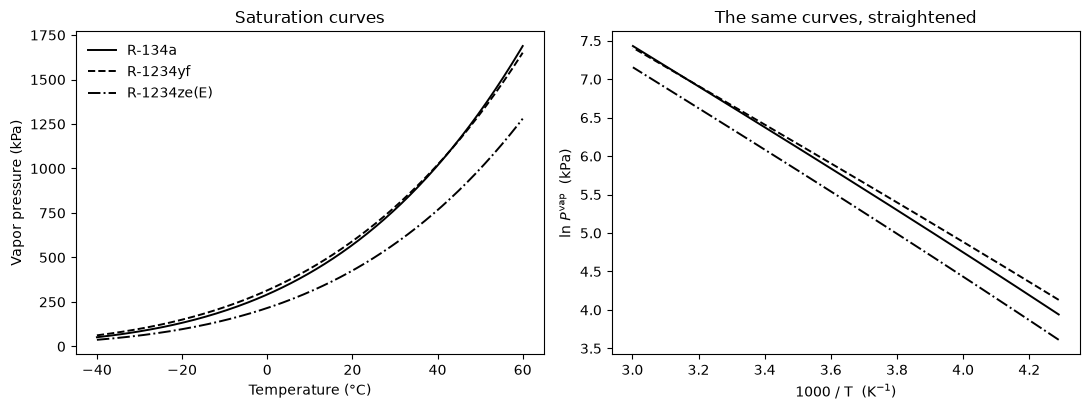

In [4]:
T_C = np.linspace(-40.0, 60.0, 201)
T_K = T_C + 273.15
STYLE = {"R-134a": "-", "R-1234yf": "--", "R-1234ze(E)": "-."}   # B&W-legible

Psat = {name: np.array([pr[name].vapor_pressure(t) for t in T_K]) / 1000.0
        for name in FLUIDS}                                       # kPa

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

for name in FLUIDS:
    ax1.plot(T_C, Psat[name], STYLE[name], color="k", lw=1.4, label=name)
ax1.set_xlabel("Temperature (°C)")
ax1.set_ylabel("Vapor pressure (kPa)")
ax1.set_title("Saturation curves")
ax1.legend(frameon=False)

for name in FLUIDS:
    ax2.plot(1000.0 / T_K, np.log(Psat[name]), STYLE[name], color="k", lw=1.4, label=name)
ax2.set_xlabel("1000 / T  (K$^{-1}$)")
ax2.set_ylabel(r"$\ln\,P^{\mathrm{vap}}$  (kPa)")
ax2.set_title("The same curves, straightened")

fig.tight_layout()
plt.show()

On the left the three curves look much alike, which is the trouble with plotting vapor pressure
directly: everything is exponential and the eye cannot judge a 25 % difference. On the right they
are nearly straight, because $\ln P^{\mathrm{vap}}$ against $1/T$ is nearly linear — the
Clausius–Clapeyron result of Chapter 7, and the reason vapor-pressure data are always plotted this
way.

Still not decisive. Plot the **ratio** to R-134a instead, and the picture resolves at once.

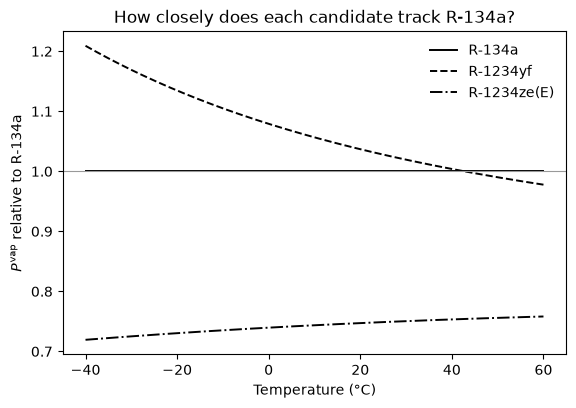

R-134a        ratio spans 1.000 to 1.000 over -40 to +60 C
R-1234yf      ratio spans 0.978 to 1.209 over -40 to +60 C
R-1234ze(E)   ratio spans 0.719 to 0.758 over -40 to +60 C


In [5]:
fig, ax = plt.subplots(figsize=(6.5, 4.2))
for name in FLUIDS:
    ax.plot(T_C, Psat[name] / Psat["R-134a"], STYLE[name], color="k", lw=1.4, label=name)
ax.axhline(1.0, color="0.6", lw=0.8)
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("$P^{\\mathrm{vap}}$ relative to R-134a")
ax.set_title("How closely does each candidate track R-134a?")
ax.legend(frameon=False)
plt.show()

for name in FLUIDS:
    r = Psat[name] / Psat["R-134a"]
    print(f"{name:<13} ratio spans {r.min():.3f} to {r.max():.3f} over -40 to +60 C")

**R-1234yf crosses R-134a.** It runs about 20 % high at −40 °C, matches it near 40 °C, and falls
2 % below at 60 °C. Over the whole range it is within roughly 20 % and for most of it within 5 %.

**R-1234ze(E) never comes close.** It sits 25 % below R-134a at every temperature, and the ratio is
almost *flat* — which says something specific: it is not a different kind of fluid, it is the same
kind of fluid shifted along the temperature axis. §5 makes that quantitative.

This already suggests which candidate can go into existing equipment. It does not settle it,
because pressure is only half the question.

## 4. The drop-in test

Take the conditions of the automobile air conditioner in Chapter 5: evaporating at **5 °C**,
condensing at **55 °C**, removing **3.5 kW** from the passenger compartment.

Three quantities decide whether a substitute fits the existing machine:

| quantity | what it constrains |
|---|---|
| $P^{\mathrm{vap}}$ at both temperatures | whether the vessels and seals can hold it |
| $\Delta_{\mathrm{vap}}\hat{H}$ | the **mass** flow rate needed |
| $\hat{V}$ of the saturated vapor | the **volume** the compressor must swallow per kilogram |

The last two are the interesting pair, because a compressor is a *volume*-displacement machine: it
admits a fixed volume of vapor per revolution and knows nothing about mass.

In [6]:
T_EVAP, T_COND, Q_DUTY = 5.0 + 273.15, 55.0 + 273.15, 3.5e3     # K, K, W


def state(name):
    """Everything the drop-in test needs, for one fluid, at the two working temperatures."""
    f, eos = FLUIDS[name], pr[name]
    M = f["M"] / 1000.0                                    # kg/mol
    Pe, Pc = eos.vapor_pressure(T_EVAP), eos.vapor_pressure(T_COND)

    # Enthalpy of vaporization: a DIFFERENCE of departure functions at one T, so the
    # ideal-gas part cancels and no Cp* is needed. J/mol -> J/kg.
    dH = (eos.departure_H(T_EVAP, Pe, "vapor")
          - eos.departure_H(T_EVAP, Pe, "liquid")) / M

    v_vap = eos.molar_volume(T_EVAP, Pe, "vapor") / M       # m^3/kg
    mdot = Q_DUTY / dH                                      # kg/s
    return dict(Pe=Pe, Pc=Pc, ratio=Pc / Pe, dH=dH, v_vap=v_vap,
                mdot=mdot, Vdot=mdot * v_vap, capacity=dH / v_vap)


S = {name: state(name) for name in FLUIDS}
b = S["R-134a"]

print(f"{'fluid':<13}{'Pevap':>8}{'Pcond':>8}{'ratio':>7}{'dHvap':>9}{'v_vap':>9}"
      f"{'mdot':>9}{'Vdot':>9}{'capacity':>10}")
print(f"{'':<13}{'kPa':>8}{'kPa':>8}{'':>7}{'kJ/kg':>9}{'m3/kg':>9}{'g/s':>9}{'L/s':>9}{'kJ/m3':>10}")
for name, s in S.items():
    print(f"{name:<13}{s['Pe']/1e3:>8.1f}{s['Pc']/1e3:>8.1f}{s['ratio']:>7.2f}"
          f"{s['dH']/1e3:>9.1f}{s['v_vap']:>9.5f}{s['mdot']*1e3:>9.2f}"
          f"{s['Vdot']*1e3:>9.3f}{s['capacity']/1e3:>10.0f}")

print(f"\n{'fluid':<13}{'Pevap':>9}{'Pcond':>9}{'per kg':>9}{'per m3':>9}   (vs R-134a)")
for name, s in S.items():
    print(f"{name:<13}{100*(s['Pe']/b['Pe']-1):>+8.1f}%{100*(s['Pc']/b['Pc']-1):>+8.1f}%"
          f"{100*(s['dH']/b['dH']-1):>+8.1f}%{100*(s['capacity']/b['capacity']-1):>+8.1f}%")

fluid           Pevap   Pcond  ratio    dHvap    v_vap     mdot     Vdot  capacity
                  kPa     kPa           kJ/kg    m3/kg      g/s      L/s     kJ/m3
R-134a          348.4  1496.0   4.29    198.0  0.05952    17.68    1.052      3326
R-1234yf        371.9  1471.7   3.96    162.4  0.04889    21.55    1.054      3322
R-1234ze(E)     258.4  1132.6   4.38    182.5  0.07267    19.18    1.394      2511

fluid            Pevap    Pcond   per kg   per m3   (vs R-134a)
R-134a           +0.0%    +0.0%    +0.0%    +0.0%
R-1234yf         +6.7%    -1.6%   -18.0%    -0.1%
R-1234ze(E)     -25.8%   -24.3%    -7.8%   -24.5%


**Read the last two columns against each other.** R-1234yf delivers **18 % less cooling per
kilogram** than R-134a. Taken alone that looks disqualifying, and it is the number a student
computing an energy balance will get first.

Per cubic meter of vapor it is **within 0.2 %**.

The reason is that the two errors cancel. R-1234yf needs 22 % more mass flow, and its saturated
vapor at 5 °C is 22 % denser, so the volumetric flow the compressor sees is the same. Worth
watching the cancellation happen rather than taking it on trust:

In [7]:
print("Why the per-kilogram penalty does not matter:\n")
print(f"{'':<24}{'R-134a':>12}{'R-1234yf':>12}{'ratio':>9}")
rows = [("cooling per kg (kJ/kg)", "dH", 1e-3),
        ("-> mass flow (g/s)",     "mdot", 1e3),
        ("vapor volume (m3/kg)",   "v_vap", 1.0),
        ("-> volume flow (L/s)",   "Vdot", 1e3)]
for label, key, scale in rows:
    a, c = b[key]*scale, S["R-1234yf"][key]*scale
    print(f"{label:<24}{a:>12.4f}{c:>12.4f}{c/a:>9.3f}")

print(f"\nR-1234yf carries {100*(S['R-1234yf']['mdot']/b['mdot']-1):.0f}% more mass per second "
      f"through vapor that is {100*(b['v_vap']/S['R-1234yf']['v_vap']-1):.0f}% denser.")
print(f"The two factors multiply to {(S['R-1234yf']['mdot']/b['mdot'])*(S['R-1234yf']['v_vap']/b['v_vap']):.4f}"
      f" -- so the same compressor, at the same speed, moves the same heat.")
print(f"\nR-1234ze(E), in the same machine, would deliver only "
      f"{Q_DUTY*S['R-1234ze(E)']['capacity']/b['capacity']/1e3:.2f} kW of the 3.50 kW required.")

Why the per-kilogram penalty does not matter:

                              R-134a    R-1234yf    ratio
cooling per kg (kJ/kg)      197.9788    162.3886    0.820
-> mass flow (g/s)           17.6787     21.5532    1.219
vapor volume (m3/kg)          0.0595      0.0489    0.821
-> volume flow (L/s)          1.0522      1.0537    1.001

R-1234yf carries 22% more mass per second through vapor that is 22% denser.
The two factors multiply to 1.0015 -- so the same compressor, at the same speed, moves the same heat.

R-1234ze(E), in the same machine, would deliver only 2.64 kW of the 3.50 kW required.


## 5. The temperature shift

§3 noticed that R-1234ze(E)'s pressure ratio to R-134a is nearly flat. A flat ratio means the fluid
behaves like R-134a evaluated at a different temperature — so ask directly: at what temperature does
each candidate reach the pressure R-134a has at 5 °C?

In [8]:
target = b["Pe"]
print(f"R-134a at 5.00 C has P_vap = {target/1e3:.1f} kPa. The others reach it at:\n")
for name in FLUIDS:
    T = brentq(lambda t: pr[name].vapor_pressure(t) - target, 200.0, FLUIDS[name]["Tc"] - 1.0)
    print(f"   {name:<13}{T-273.15:>7.2f} C     (a shift of {T-T_EVAP:+.2f} K)")

R-134a at 5.00 C has P_vap = 348.4 kPa. The others reach it at:

   R-134a          5.00 C     (a shift of +0.00 K)
   R-1234yf        3.02 C     (a shift of -1.98 K)
   R-1234ze(E)    13.76 C     (a shift of +8.76 K)


**Two kelvin against nine.** An evaporator designed to hold 348 kPa will run within two degrees of
its design temperature on R-1234yf, and nine degrees away from it on R-1234ze(E) — the difference
between a fluid you can charge into the existing machine and a fluid the machine has to be
redesigned around.

None of which makes R-1234ze(E) a bad refrigerant. It is used in chillers and high-temperature heat
pumps built for it, where its higher critical temperature is an advantage. It is simply not a
**drop-in**, and that is a statement about matching two fluids to one machine, not about either
fluid alone.

## 6. What the second law has to say about the choice

Nothing. And it is worth seeing why, because it is a common misreading of Chapter 4.

The coefficient of performance of a *reversible* refrigeration cycle between two temperatures is
$T_{\mathrm{evap}}/(T_{\mathrm{cond}} - T_{\mathrm{evap}})$ — a result containing no property of
the working fluid at all.

In [9]:
cop_rev = T_EVAP / (T_COND - T_EVAP)
print(f"Reversible c.o.p. between 5 and 55 C = {cop_rev:.3f}  -- for every fluid, identically.\n")

print("Yet the fluids plainly differ in their entropies of vaporization at 5 C:")
for name, s in S.items():
    print(f"   {name:<13} dS_vap = {s['dH']/T_EVAP:>7.1f} J/(kg K)"
          f"    dH_vap = {s['dH']/1e3:>5.1f} kJ/kg")
print("\nBoth statements are true. dS_vap is a property of one kilogram undergoing one step;")
print("the c.o.p. is a ratio of rates around the whole cycle. A fluid with a smaller dS_vap")
print("simply circulates faster (section 4), and the entropy carried per second comes out the same.")

Reversible c.o.p. between 5 and 55 C = 5.563  -- for every fluid, identically.

Yet the fluids plainly differ in their entropies of vaporization at 5 C:
   R-134a        dS_vap =   711.8 J/(kg K)    dH_vap = 198.0 kJ/kg
   R-1234yf      dS_vap =   583.8 J/(kg K)    dH_vap = 162.4 kJ/kg
   R-1234ze(E)   dS_vap =   656.1 J/(kg K)    dH_vap = 182.5 kJ/kg

Both statements are true. dS_vap is a property of one kilogram undergoing one step;
the c.o.p. is a ratio of rates around the whole cycle. A fluid with a smaller dS_vap
simply circulates faster (section 4), and the entropy carried per second comes out the same.


So the second law sets a ceiling that every candidate shares, and the choice between candidates is
made entirely by the things §4 and §5 measured — the pressure levels and the volumetric capacity —
together with the things thermodynamics does not speak to at all: flammability, toxicity, cost,
compatibility with the lubricant, and the global warming potential that started the whole
substitution.

That division is the useful lesson. **Thermodynamics does not tell you which refrigerant to use. It
tells you which candidates will work in the machine you already have**, and that turns out to be
the question that decided the industry's answer.

## 7. The table Problem 3.N6 prints

The problem statement is self-contained — a student solves it from the table, without running
anything. This is where the table comes from, rounded to the precision the problem quotes.

In [10]:
os.makedirs("output", exist_ok=True)
lines = []
lines.append("Property table for Problem 3.N6, computed from the Peng-Robinson equation of state.")
lines.append("Evaporator 5 C, condenser 55 C.  Constants and their provenance: see")
lines.append("revision_notes/refrigerant_problems.md -- PROVISIONAL, pending citation.")
lines.append("")
hdr = f"{'':<44}" + "".join(f"{n:>14}" for n in FLUIDS)
lines.append(hdr)
for label, fmt, get in (
        ("molar mass (g/mol)",                    "{:>14.1f}", lambda n: FLUIDS[n]["M"]),
        ("P_vap at 5 C (kPa)",                    "{:>14.0f}", lambda n: S[n]["Pe"]/1e3),
        ("P_vap at 55 C (kPa)",                   "{:>14.0f}", lambda n: S[n]["Pc"]/1e3),
        ("dH_vap at 5 C (kJ/kg)",                 "{:>14.1f}", lambda n: S[n]["dH"]/1e3),
        ("sat. vapor spec. volume at 5 C (m3/kg)","{:>14.4f}", lambda n: S[n]["v_vap"]),
):
    lines.append(f"{label:<44}" + "".join(fmt.format(get(n)) for n in FLUIDS))
lines.append("")
lines.append("Derived (the answer to the problem, not printed in the statement):")
for label, fmt, get in (
        ("P_cond / P_evap",                       "{:>14.2f}", lambda n: S[n]["ratio"]),
        ("mass flow for 3.5 kW (g/s)",            "{:>14.2f}", lambda n: S[n]["mdot"]*1e3),
        ("vapor volume flow (L/s)",               "{:>14.3f}", lambda n: S[n]["Vdot"]*1e3),
        ("volumetric capacity (kJ/m3)",           "{:>14.0f}", lambda n: S[n]["capacity"]/1e3),
):
    lines.append(f"{label:<44}" + "".join(fmt.format(get(n)) for n in FLUIDS))

text = "\n".join(lines)
with open("output/Problem_3.N6_table.txt", "w") as fh:
    fh.write(text + "\n")
print(text)
print("\n-> written to output/Problem_3.N6_table.txt")

Property table for Problem 3.N6, computed from the Peng-Robinson equation of state.
Evaporator 5 C, condenser 55 C.  Constants and their provenance: see
revision_notes/refrigerant_problems.md -- PROVISIONAL, pending citation.

                                                    R-134a      R-1234yf   R-1234ze(E)
molar mass (g/mol)                                   102.0         114.0         114.0
P_vap at 5 C (kPa)                                     348           372           258
P_vap at 55 C (kPa)                                   1496          1472          1133
dH_vap at 5 C (kJ/kg)                                198.0         162.4         182.5
sat. vapor spec. volume at 5 C (m3/kg)              0.0595        0.0489        0.0727

Derived (the answer to the problem, not printed in the statement):
P_cond / P_evap                                       4.29          3.96          4.38
mass flow for 3.5 kW (g/s)                           17.68         21.55         19.18
vapor vol

## What this notebook shows

- **A substitute refrigerant has to match the old fluid's *volumetric* refrigeration capacity, not
  its heat of vaporization.** R-1234yf gives 18 % less cooling per kilogram and the same cooling per
  cubic meter, because its vapor is correspondingly denser. Compressors meter volume.
- **That is why R-1234yf replaced HFC-134a in cars** — capacity within 0.2 %, pressures within a few
  percent, a slightly easier pressure ratio.
- **And why R-1234ze(E) did not**, despite an equally low warming potential: 25 % less capacity and
  a 9 K shift in its saturation curve. It needs a machine built for it.
- **Three constants per fluid were enough.** No ideal-gas heat capacity appears anywhere, because
  every property used is either a volume root or a difference of departure functions at one
  temperature, where the ideal-gas part cancels.
- **The reversible coefficient of performance is the same for all three fluids**, so the second law
  does not choose between them. It sets a ceiling; the pressure levels and the vapor density decide
  what fits the equipment.
- **Check a model against published numbers before believing it.** §2 reproduces the book's own
  printed vapor pressures exactly and the boiling points to a few tenths of a kelvin — and states
  where that accuracy would *not* be enough.

## Things to try

1. Repeat §4 for a domestic refrigerator: evaporator −25 °C, condenser 40 °C. Does R-1234yf remain
   a volumetric match for R-134a over that much wider span?
2. Isobutane (R-600a, $T_c = 407.8$ K, $P_c = 3.629$ MPa, $\omega = 0.184$, $M = 58.12$) is the
   refrigerant in most new household refrigerators. Add it to `FLUIDS` and compare. Its volumetric
   capacity is far lower than R-134a's — so why is it used, and what does that tell you about how
   much the drop-in constraint matters when the machine is designed from scratch?
3. Plot volumetric capacity against evaporator temperature from −40 to +10 °C for all three fluids.
   Do the curves cross? The single number in §4 is one point on those curves.
4. §2 warns that PR is not accurate enough to draw a pressure–enthalpy chart. Test the claim: the
   enthalpy of vaporization of R-134a at 5 °C from the reference equation of state is
   197.6 kJ/kg. How far off is PR, and how does that error compare with the 0.2 % capacity
   difference the conclusion in §4 rests on?